In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [28]:
df=pd.read_csv("ice_cream_selling_data.csv")

In [29]:
df

,Temperature (C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531
5,-3.455712,30.001138
6,-3.108440,22.635401
7,-3.081303,25.365022
8,-2.672461,19.226970
9,-2.652287,20.279679


In [30]:
X=df["Temperature (C)"]
y=df["Ice Cream Sales (units)"]

In [31]:
X=pd.DataFrame(X)

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.2,random_state=42)

In [33]:
from sklearn.linear_model import Ridge
model=Ridge(alpha=10)

In [34]:
model.fit(X_train,y_train)

Ridge(alpha=10)

In [35]:
print("Alpha=10")
print(pd.Series(model.coef_,index=X.columns))

Alpha=10
Temperature (C)   -1.109533
dtype: float64


In [36]:
y_pred=model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score
print(r2_score(y_test,y_pred))

-0.5665886936594831


Alpha=0.01| Coefficient=[-1.14654857]| r2_score=-0.575118116001925
Alpha=0.012648552168552958| Coefficient=[-1.14653843]| r2_score=-0.5751157581295752
Alpha=0.015998587196060583| Coefficient=[-1.14652561]| r2_score=-0.5751127758387622
Alpha=0.020235896477251575| Coefficient=[-1.14650938]| r2_score=-0.5751090037947779
Alpha=0.025595479226995357| Coefficient=[-1.14648887]| r2_score=-0.5751042329006155
Alpha=0.032374575428176434| Coefficient=[-1.14646291]| r2_score=-0.5750981987227521
Alpha=0.040949150623804255| Coefficient=[-1.14643009]| r2_score=-0.57509056686133
Alpha=0.05179474679231213| Coefficient=[-1.14638857]| r2_score=-0.5750809144613227
Alpha=0.0655128556859551| Coefficient=[-1.14633607]| r2_score=-0.5750687068520974
Alpha=0.08286427728546843| Coefficient=[-1.14626966]| r2_score=-0.5750532680401992
Alpha=0.10481131341546858| Coefficient=[-1.14618567]| r2_score=-0.5750337434515398
Alpha=0.13257113655901095| Coefficient=[-1.14607946]| r2_score=-0.5750090529088063
Alpha=0.167683293

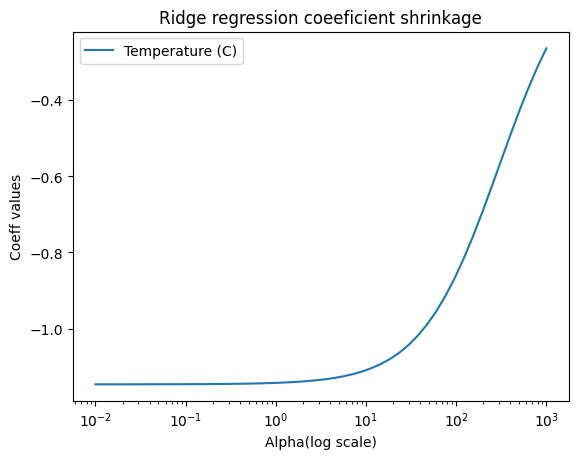

In [39]:
alphas=np.logspace(-2,3,50)
coeff_path=[]
for alph in alphas:
    model=Ridge(alpha=alph)
    model.fit(X_train,y_train)
    y_pred1=model.predict(X_test)
    coeff_path.append(model.coef_)
    print(f"Alpha={alph}| Coefficient={model.coef_}| r2_score={r2_score(y_test,y_pred1)}")
coeff_path=np.array(coeff_path)
plt.plot(alphas,coeff_path)
plt.xscale("log")
plt.xlabel("Alpha(log scale)")
plt.ylabel("Coeff values")
plt.title("Ridge regression coeeficient shrinkage")
plt.legend(X.columns)